In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.visualizacao import aplicar_estilo_dark, estilizar_grafico, adicionar_valores_barras, COR_VERMELHO, COR_AZUL

aplicar_estilo_dark()

In [2]:
df = pd.read_csv("../data/processed/dataset_final_resumo_limpo.csv")

top_kd = df.groupby("Fighter")["KD"].sum().sort_values(ascending=False).head(10)

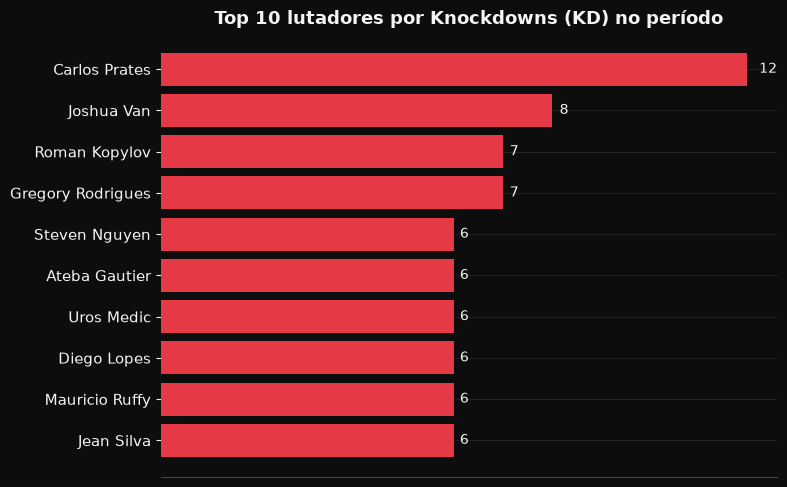

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_kd.index[::-1], top_kd.values[::-1], color=COR_VERMELHO)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por Knockdowns (KD) no período")

plt.tight_layout()
plt.savefig("../figures/top10_kd.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

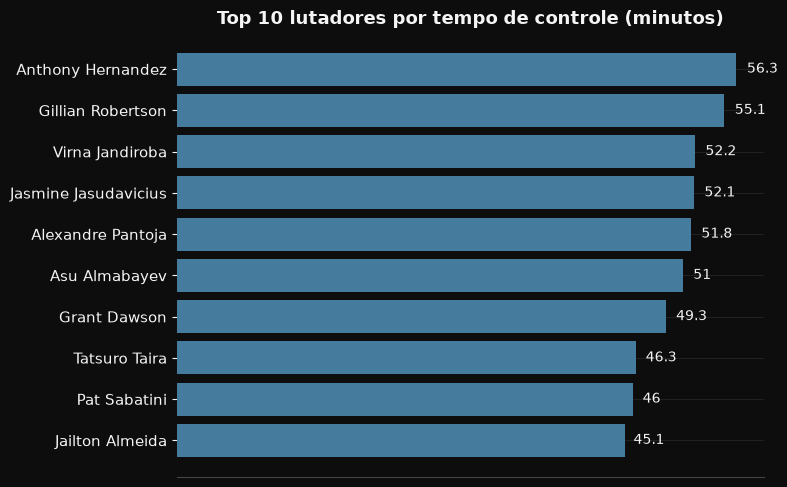

In [4]:
df_proc = pd.read_csv("../data/processed/dataset_24eventos_resumo_limpo.csv") if False else pd.read_csv("../data/processed/dataset_final_resumo_limpo.csv")

top_ctrl = df_proc.groupby("Fighter")["Ctrl_seconds"].sum().sort_values(ascending=False).head(10)
top_ctrl_min = (top_ctrl / 60).round(1)  # converter para minutos, mais legível

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_ctrl_min.index[::-1], top_ctrl_min.values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por tempo de controle (minutos)")

plt.tight_layout()
plt.savefig("../figures/top10_ctrl.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

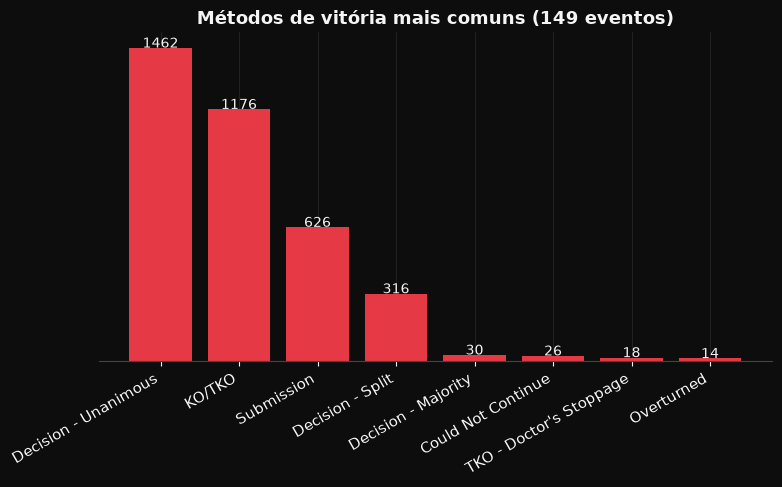

In [5]:
metodos = df["Method"].value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(metodos.index, metodos.values, color=COR_VERMELHO)

for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 2,
            f"{int(altura)}", ha="center", fontsize=10, color="#f5f5f5")

ax.set_title("Métodos de vitória mais comuns (149 eventos)", fontsize=13, fontweight="bold")
ax.set_yticks([])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/metodos_vitoria.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

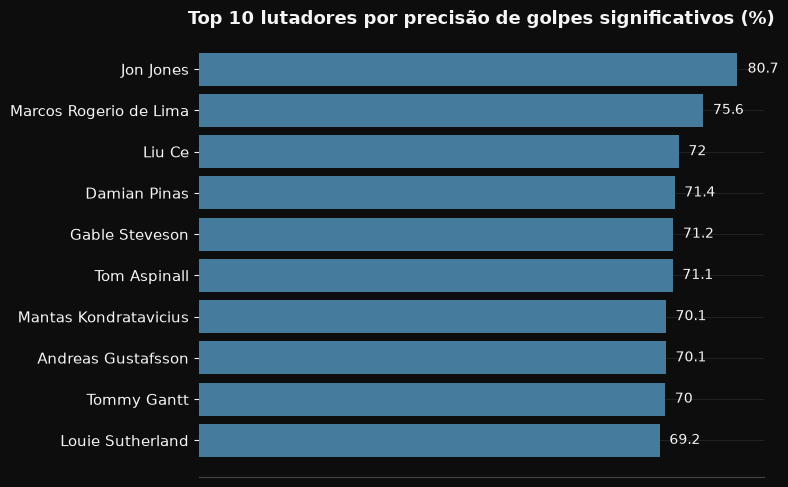

In [6]:
precisao = df.groupby("Fighter").agg(
    total_landed=("Sig_str_landed", "sum"),
    total_attempted=("Sig_str_attempted", "sum")
)
precisao = precisao[precisao["total_attempted"] >= 50]  # filtro: pelo menos 50 tentativas no período
precisao["precisao_pct"] = (precisao["total_landed"] / precisao["total_attempted"] * 100).round(1)

top_precisao = precisao.sort_values("precisao_pct", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_precisao.index[::-1], top_precisao["precisao_pct"].values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por precisão de golpes significativos (%)")

plt.tight_layout()
plt.savefig("../figures/top10_precisao.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

In [9]:
def comparar_lutadores(nome1, nome2, df):
    metricas = ["Sig_str_landed", "Total_str_landed", "Td_landed", "Sub. att", "KD"]
    labels = ["Golpes Sig. (méd/luta)", "Golpes Totais (méd/luta)", "Quedas (méd/luta)", "Finaliz. Tent. (méd/luta)", "Knockdowns (méd/luta)"]

    df1 = df[df["Fighter"] == nome1]
    df2 = df[df["Fighter"] == nome2]

    n_lutas1 = len(df1)
    n_lutas2 = len(df2)

    dados1 = df1[metricas].mean().round(1)
    dados2 = df2[metricas].mean().round(1)

    y_pos = range(len(metricas))
    escala_max = max(dados1.max(), dados2.max())

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(y_pos, -dados1.values, color=COR_AZUL, label=f"{nome1} ({n_lutas1} lutas)")
    ax.barh(y_pos, dados2.values, color=COR_VERMELHO, label=f"{nome2} ({n_lutas2} lutas)")

    for i, v in enumerate(dados1.values):
        ax.text(-v - (escala_max * 0.03), i, f"{v}", va="center", ha="right", fontsize=10, color="#f5f5f5")
    for i, v in enumerate(dados2.values):
        ax.text(v + (escala_max * 0.03), i, f"{v}", va="center", ha="left", fontsize=10, color="#f5f5f5")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xticks([])
    ax.set_title(f"{nome1}  vs  {nome2}  —  médias por luta", fontsize=14, fontweight="bold")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, labelcolor="#f5f5f5")

    plt.tight_layout()
    nome_arquivo = f"../figures/comparacao_{nome1.replace(' ', '_')}_vs_{nome2.replace(' ', '_')}.png"
    plt.savefig(nome_arquivo, dpi=150, facecolor=fig.get_facecolor())
    plt.show()

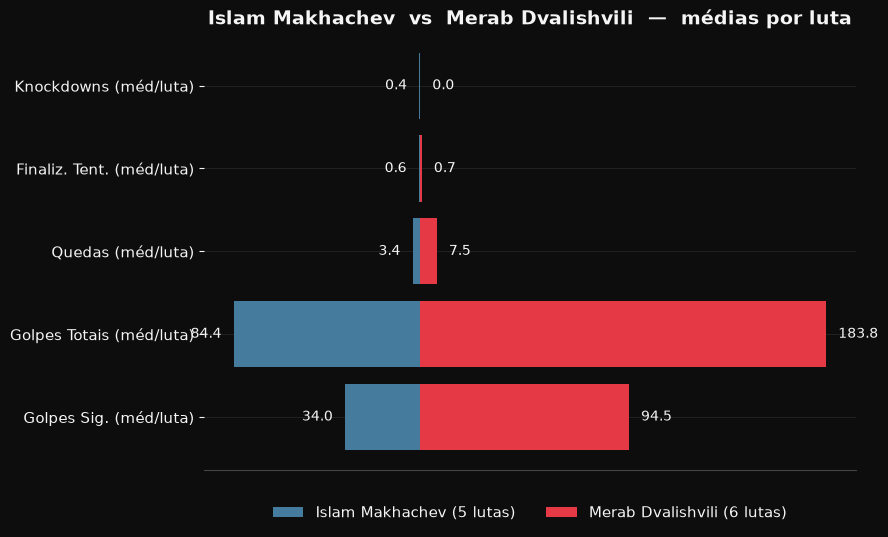

In [12]:
comparar_lutadores("Islam Makhachev", "Merab Dvalishvili", df)

In [13]:
df_round = pd.read_csv("../data/processed/dataset_final_round_limpo.csv")

media_por_round = df_round.groupby("Round")["Sig_str_landed"].mean().round(1)
print(media_por_round)

Round
1    16.2
2    18.9
3    19.7
4    19.6
5    20.5
Name: Sig_str_landed, dtype: float64


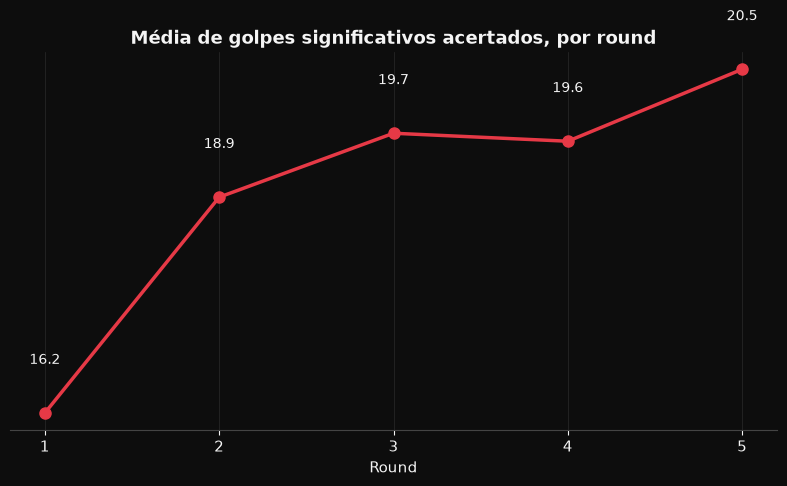

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(media_por_round.index, media_por_round.values, color=COR_VERMELHO,
        marker="o", markersize=8, linewidth=2.5)

for x, y in zip(media_por_round.index, media_por_round.values):
    ax.text(x, y + (media_por_round.max() * 0.03), f"{y}",
            ha="center", fontsize=10, color="#f5f5f5")

ax.set_title("Média de golpes significativos acertados, por round", fontsize=13, fontweight="bold")
ax.set_xlabel("Round")
ax.set_xticks(media_por_round.index)
ax.set_yticks([])
plt.tight_layout()
plt.savefig("../figures/evolucao_golpes_por_round.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

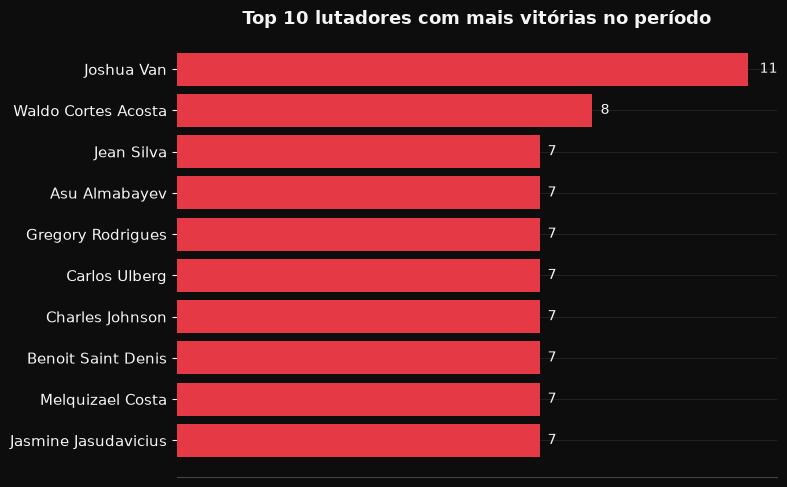

In [15]:
vitorias = df[df["Resultado"] == "W"].groupby("Fighter").size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(vitorias.index[::-1], vitorias.values[::-1], color=COR_VERMELHO)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores com mais vitórias no período")

plt.tight_layout()
plt.savefig("../figures/top10_vitorias.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

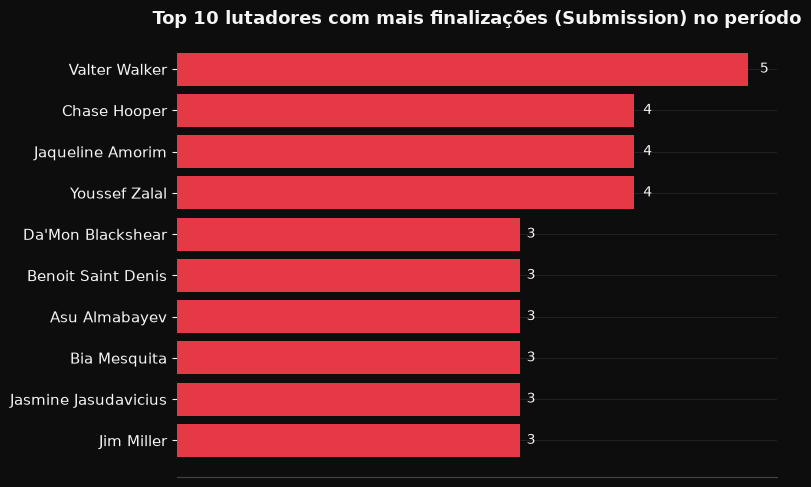

In [17]:
finalizacoes = df[
    (df["Resultado"] == "W") & (df["Method"].str.contains("Submission", na=False))
].groupby("Fighter").size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(finalizacoes.index[::-1], finalizacoes.values[::-1], color=COR_VERMELHO)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores com mais finalizações (Submission) no período")

plt.tight_layout()
plt.savefig("../figures/top10_finalizacoes.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

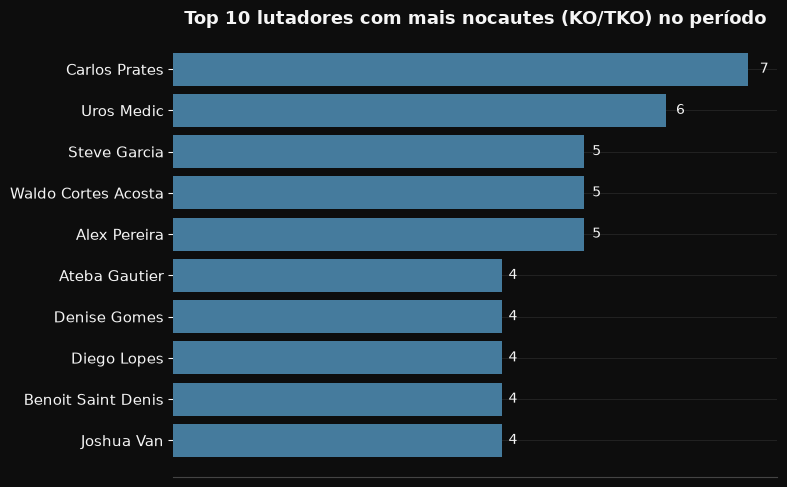

In [18]:
nocautes = df[
    (df["Resultado"] == "W") & (df["Method"].str.contains("KO/TKO", na=False))
].groupby("Fighter").size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(nocautes.index[::-1], nocautes.values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores com mais nocautes (KO/TKO) no período")

plt.tight_layout()
plt.savefig("../figures/top10_nocautes.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()